# 2. Hierarchical Bayesian Inference

We use the `emcee` package to compute and plot the posterior for the hierarchical Bayesian inference problem from Homework 1 Question 3.

#### The problem

We use a hierarchical Bayesian framework to fit AGN lightcurves.

- **Population-level params:**
    - SMBH mass $M_{SMBH}$ distribution: empirical distribution, e.g. black hole mass function from surveys (see [Kelly 2018](https://arxiv.org/pdf/1112.1430) for example)<br>
      For simplicity, we set this ditribution to be normal (a more realistic mass function can be implemented later)
      $$M_{BH} \sim \mathcal{N}(\mu_M, \sigma_M)$$
- **Individual-level params:** <br>
  AGN time-series models will generally be described with paramaters for a damped random walk (DRW) -- we will not include quasi-periodic oscillation (QPO) signal for simplicity-- which can be fit with a gaussian process:
  $$ y(t) \sim \mathcal{GP}(\mu=0, k_{DRW}(\tau, \sigma_{DRW})) $$
    - characteristic timescale $\tau$: related to $M_{SMBH}$ through empirical scaling relations (see [MacLeod 2010](https://arxiv.org/pdf/1004.0276)), we use a simplified power law relation
      $$ \tau \propto M_{BH}^{\beta}\quad \text{where $\beta=0.5$}\quad \implies \log \tau = \beta \log M_{BH} + \text{const.}$$
    - signal variance amplitude $\sigma_\rm{DRW}^2$: decided to set to a global constant value. Inferring extra parameters significantly complicates analysis (my original code had a progress bar predicting 12 hrs of computation!)

> Note: For binary SMBHs, we could have done inference on individual-level params like orbital frequency (often related to QPO $\omega$, for example) from population-level params from the power spectrum of gravitational wave background (GWB) from PTA experiments (see [NANOGrav 2023](https://arxiv.org/pdf/2306.16213) for some intro discussion of SMBHB contibution to GWB).


## Simulated data 
We define true SMBH population distribution to be $\log M_{BH} \sim \mathcal{N}(\mu_M, \sigma_M)$.

We sample $M_{SMBH}$ from this assumed SMBH mass distribution and generate corresponding lighcurves using EzTaoX.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

#### Generate SMBH population

In [2]:
key = jax.random.PRNGKey(0)

n_smbh = 50 # nbr of AGN lightcurves

# M: SMBH masses in sol mass
logM_mu = 8
logM_sigma = 0.5

key, subkey = jax.random.split(key)
logM = jax.random.normal(subkey, (n_smbh,)) * logM_sigma + logM_mu

# tau_DRW: characteristic timescale depends on mass log(tau) = const + beta* log(M_BH)
logTau_const = -2.0 
logTau_beta = 0.8
logTau_sigma = 0.3 
key, subkey = jax.random.split(key)
logTau = (logTau_const 
          + logTau_beta * logM 
          + jax.random.normal(subkey, (n_smbh,)) * logTau_sigma)

# sigma_DRW: global lightcurve variance
logSigma_drw = log_sigma_global = jnp.log(jnp.array(0.15))#np.log(0.15)

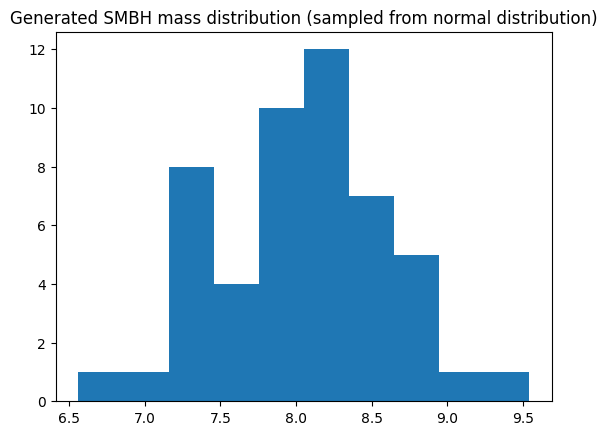

In [3]:
# visualize
plt.title('Generated SMBH mass distribution (sampled from normal distribution)')
plt.hist(logM)
plt.show()

#### Generate light curves

In [4]:
# GENERATE LIGHTCURVES
from eztaox.kernels.quasisep import Exp
from eztaox.simulator import UniVarSim
from eztaox.ts_utils import add_noise

# simulate univariate (i.e. single-band) lightcurves
data = []
min_dt, max_dt = 1.0, 3650.0 # days

for i in range(n_smbh):

    # setup single band DRW lightcurve model
    sim_params = {"log_kernel_param": jnp.asarray([logTau[i], logSigma_drw])}
    k = Exp(*sim_params["log_kernel_param"]) # DRW kernel 
    s = UniVarSim(k, min_dt, max_dt, sim_params) # simulator

    # simulate light curve, add noise
    sim_t, sim_y = s.random(200, jax.random.PRNGKey(i), jax.random.PRNGKey(i+100))
    sim_yerr = jnp.ones_like(sim_t) * 0.05
    sim_y_noisy = add_noise(sim_y, sim_yerr, jax.random.PRNGKey(i+200))

    data.append((np.array(sim_t), np.array(sim_y_noisy), np.array(sim_yerr)))

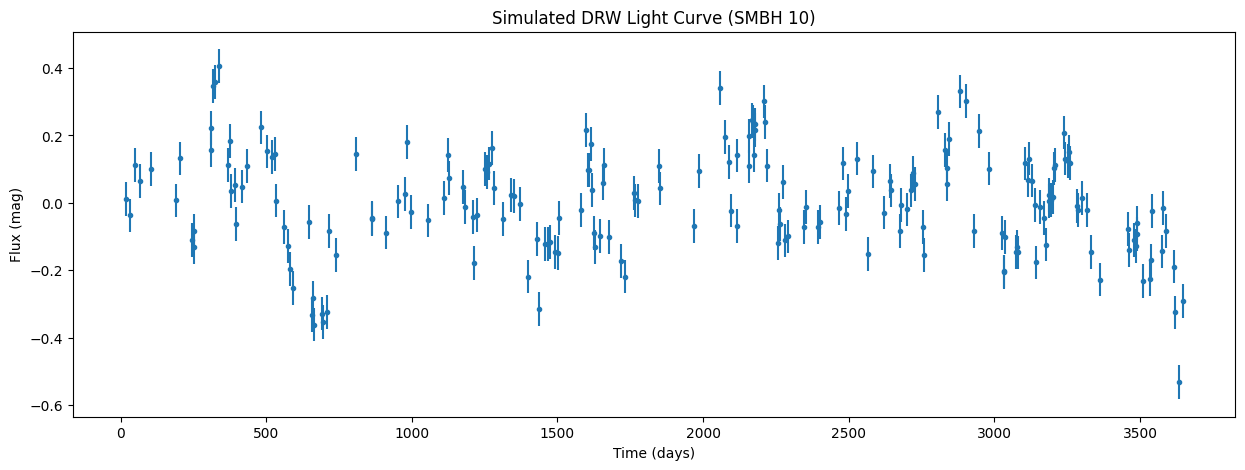

In [5]:
# visualize
i = 10
_t, _y, _yerr = data[i]

plt.figure(figsize=(15,5))
plt.title(f"Simulated DRW Light Curve (SMBH {i})")
plt.errorbar(_t, _y, _yerr, fmt=".")
plt.xlabel("Time (days)"); plt.ylabel("Flux (mag)")
plt.show()

#### Hierarchical Bayesian Inference

- For each SMBH AGN $i$, the lightcurve can be described by DRW -- fit by Gaussian Process
  $$ y_i(t)\sim \mathcal{GP}(0, k_{DRW}(\tau_i, \sigma))$$
  and some observational noise accounted for with gaussian error bars $\sigma_{obs}$, such that the **individual-level likelihood** is
  $$ p(y_i | \tau_i(M_i), \sigma) = \mathcal{N}(0, k_{DRW}+\sigma_{obs}^2 I). $$

  where we use scaling relations to relate to param $M_{i}$ with $\tau_i$
$$ \log{\tau_i} = \alpha + \beta \log{M_i}. $$

- We assume a SMBH mass distribution
  $$ \log M_i \sim \mathcal{N}(\mu_m, \sigma_M^2) $$
  such that the **population-level likelihood** is
  $$ p(M_i|\mu_m, \sigma_M)=\prod_i \mathcal{N}(\log M_i | \mu_M, \sigma_M^2) $$


- The resulting **posterior** is

  $$ p(\theta, M|y)\propto \left(\prod_i  p(y_i|\tau_i(M_i),\theta) \, p(M_i|\mu_m, \sigma_M) \right) p(\theta)$$

  where $\theta=(\alpha_\tau, \beta_tau, \mu_M, \sigma_M, \sigma_{DRW} )$ and $p(\theta)$ is the hyperprior.

In [26]:
from tinygp import GaussianProcess#, kernels
import jax.numpy as jnp
from eztaox.kernels.quasisep import Exp

def log_likelihood(y, t, log_tau, log_sigma, yerr):
    """ Calculates likelihood using gaussian process """
    kernel = Exp(scale=log_tau, sigma=log_sigma)
    gp = GaussianProcess(kernel, t, diag=yerr**2) # likelihood
    return float(gp.log_probability(y))

In [27]:
def log_hyperprior(a_tau, b_tau, mu_M, sigma_M, log_sigma_global):
    """ Calculates flat prior """
    if not (-5 < a_tau < 5 and -5 < b_tau < 5):
        return -np.inf # log 0 --> -infty
    if not (5 < mu_M < 11 and 0 < sigma_M < 2): 
        return -np.inf
    if not (-5 < log_sigma_global < 2):
        return -np.inf
    return 0.0 # log 1 = 0

In [28]:
def log_posterior(theta, data):
    # unpack params
    N = len(data)
    a_tau, b_tau, mu_M, sigma_M, log_sigma_global = theta[:5] 
    logM = theta[5:]
    # log prob posterior
    lp = log_hyperprior(a_tau, b_tau, mu_M, sigma_M, log_sigma_global)
    for i in range(N):
        t, y, yerr = data[i]
        log_tau = a_tau + b_tau * logM[i] # mass to tau scaling
        lp += -0.5 * ((logM[i] - mu_M)**2 / sigma_M**2) - np.log(sigma_M) # mass distribution prior
        lp += log_likelihood(y, t, log_tau, log_sigma_global, yerr)
    return lp

In [46]:
# total number of parameters: 5 hyperparameters + n_smbh masses (log(M_BH))
ndim = 5 + n_smbh  # 5 hyperparameters + n_smbh masses (log(M_BH))

# initial guess
p0 = np.zeros((nwalkers, ndim))
p0[:, 0] = np.random.normal(-2.0, 0.5, nwalkers)  # a_tau
p0[:, 1] = np.random.normal(0.8, 0.2, nwalkers)   # b_tau
p0[:, 2] = np.random.normal(8.0, 1.0, nwalkers)   # mu_M
p0[:, 3] = np.random.normal(0.5, 0.2, nwalkers)   # sigma_M
p0[:, 4] = np.random.normal(np.log(0.15), 0.2, nwalkers)  # log(sigma_global)
p0[:, 5:] = np.random.normal(8.0, 1.0, (nwalkers, n_smbh))  # log(M_BH)

#### run fails :(
I cant figure out the bug... 

I tried using tinygp kernel, instead of ExtaoX's wrapper kernel, but it didnt change much. I also tried using numpyro.infer MCMC instead (like in EzTaoX tutorials), but that wasnt the issue. There must be an error with my hierarchical bayes setup, maybe the way I handled my latent scaling parameters? I played around alot with keeping things in log or not, bc of EzTaoX vs tinygp, so I mightve messed up there too.

I tried chatgpt debugging too (last cell) but it would just lead me in circles. 

In [53]:
# run MCMC sampling
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[data])
sampler.run_mcmc(p0, 2000, progress=True)

  0%|          | 0/2000 [00:00<?, ?it/s]C:\Users\sarab\AppData\Local\Temp\ipykernel_29892\809000442.py:60: RuntimeWarning: invalid value encountered in log
  total += -0.5 * ((logM[i] - mu_M)**2 / sigma_M**2) - np.log(sigma_M)
  0%|          | 0/2000 [00:21<?, ?it/s]


ValueError: Probability function returned NaN

In [52]:
import numpy as np
import jax.numpy as jnp
from tinygp import GaussianProcess, kernels

def log_likelihood(y, t, log_tau, log_sigma, yerr):
    """ Calculates likelihood using Gaussian process """
    
    log_tau = jnp.asarray(log_tau)  # Ensure it's a JAX array
    log_sigma = jnp.asarray(log_sigma)
    
    # Debugging step: Check for NaN values in the parameters
    if jnp.any(jnp.isnan(log_tau)) or jnp.any(jnp.isnan(log_sigma)):
        print(f"NaN detected in log_tau or log_sigma: log_tau = {log_tau}, log_sigma = {log_sigma}")
    
    assert log_tau.shape == ()  # log_tau should be scalar
    assert log_sigma.shape == ()  # log_sigma should be scalar
    
    # Create the kernel with the appropriate log parameters
    try:
        kernel = Exp(scale=log_tau, sigma=log_sigma)
        #kernel = kernels.Exp(jnp.asarray([jnp.exp(log_tau), jnp.exp(log_sigma_global)]))
    except Exception as e:
        print(f"Error in kernel initialization: {e}")
        return -np.inf  # Return -inf if there's an error
    
    # Gaussian process likelihood calculation
    try:
        gp = GaussianProcess(kernel, t, diag=yerr**2)
        return float(gp.log_probability(y))
    except Exception as e:
        print(f"Error in GaussianProcess calculation: {e}")
        return -np.inf  # Return -inf if GaussianProcess fails

def log_posterior(theta, data):
    N = len(data)

    # Unpack parameters
    a_tau, b_tau, mu_M, sigma_M, log_sigma_global = theta[:5]  # First 5 parameters
    logM = theta[5:]

    # Check the unpacked parameters
    #print(f"Parameters: a_tau = {a_tau}, b_tau = {b_tau}, mu_M = {mu_M}, sigma_M = {sigma_M}, log_sigma_global = {log_sigma_global}")
    
    # Calculate the hyperprior
    lp = log_hyperprior(a_tau, b_tau, mu_M, sigma_M, log_sigma_global)
    total = lp

    # Iterate over the data to compute the likelihood
    for i in range(N):
        t, y, yerr = data[i]

        # Calculate log_tau for the current mass
        log_tau = a_tau + b_tau * logM[i]  # Mass to tau scaling

        # Debugging step: Check if logM[i] is NaN
        if jnp.any(jnp.isnan(logM[i])):
            print(f"NaN detected in logM[i] = {logM[i]}")

        # Mass distribution prior
        total += -0.5 * ((logM[i] - mu_M)**2 / sigma_M**2) - np.log(sigma_M)

        # Add the likelihood term
        total += log_likelihood(y, t, log_tau, log_sigma_global, yerr)

    return total

In [ ]:
samples = sampler.get_chain(discard=500, thin=10, flat=True)

In [ ]:
import corner

hyper_samples = samples[:, :5]
labels = ["a_tau", "b_tau", "mu_M", "sigma_M", "log_sigma_global"]
corner.corner(hyper_samples[:, :5], labels=labels)
plt.show()